In [1]:
import pandas as pd
from pathlib import Path
import numpy as np
from STiMetaD import STiMetaD
proteins = ['chignolin', 'YYCPETGTWY', 'YYDPETGTWE', 'YYRPETGTWY', 'YYAPETGTWY', 'YYDPETGQWY', 'YYDPETGTWG', 'YYDPETGTWQ', 'YYNPETGTWY', 'YYEPETGTWY', 'YYDPETGTWR', 'YYDPETGVWY', 'YYDPETGYWY', 'YYDPETGTWV', 'YYDPETGRWY']

thresholds = np.arange(0.2, 0.50, 0.04)

In [2]:
import pandas as pd
from pathlib import Path


all_mfpt = {protein: {th: [] for th in thresholds} for protein in proteins}


def read_colvar_with_fields(path):
    with open(path, "r") as f:
        header = f.readline().strip()
    parts = header.split()
    if len(parts) < 3 or parts[0] != "#!" or parts[1] != "FIELDS":
        raise ValueError(f"Unexpected FIELDS header in {path}: {header}")
    names = parts[2:]
    return pd.read_csv(path, sep=r"\s+", comment="#", names=names, engine="python")

for protein in proteins:
    base_path = Path(f"../data/{protein}/output")
    for i in range(4000, 4200):
        index_str = f"{i:03}"
        run_path = base_path / f"run_{index_str}" / f"HLDA_COLVAR_{index_str}"
        try:
            df = read_colvar_with_fields(run_path)
        except FileNotFoundError:
            print(f"Missing: {run_path}")
            continue
        if not {"time", "metad.acc", "rmsd"}.issubset(df.columns):
            print(f"Missing required columns in {run_path}")
            continue

        passed = set()
        for _, row in df.iterrows():
            time = row["time"]
            acc = row["metad.acc"]
            rmsd = row["rmsd"]
            predicted = time * acc
            for th in thresholds:
                if th not in passed and rmsd > th:
                    all_mfpt[protein][th].append(predicted)
                    passed.add(th)
            if len(passed) == len(thresholds):
                break



Missing: ../data/YYDPETGTWV/output/run_4145/HLDA_COLVAR_4145
Missing: ../data/YYDPETGTWV/output/run_4147/HLDA_COLVAR_4147
Missing: ../data/YYDPETGTWV/output/run_4150/HLDA_COLVAR_4150
Missing: ../data/YYDPETGTWV/output/run_4157/HLDA_COLVAR_4157


In [2]:
import pickle

# with open("../data/mfpt-pace=25000.pkl", "wb") as f:
#     pickle.dump(all_mfpt, f)
    
from scipy import optimize, stats


def obtainEstimationsDataFrame(samples, minSampleSize):
    samples.sort()

    survival = np.array(
        [(len(samples) - i) / len(samples) for i in range(len(samples))]
    )
    predictions = []
    R2s: list[Unknown] = []
    limits: int = []
    for limit in range(minSampleSize, len(samples)):
        firstSamples = samples[:limit]
        k = -sum(firstSamples* np.log(survival[:limit])) / sum(
            firstSamples ** 2
        )
        predictions.append(k)
        R2s.append(
            1
            - sum((np.log(survival[:limit]) + k * firstSamples) ** 2)
            / sum((np.log(survival[:limit]) - np.log(survival[:limit]).mean()) ** 2)
        )
        limits.append(limit)

    return pd.DataFrame(
        {"Tstar": samples[minSampleSize:], "prediction": predictions, "R2": R2s, "limit": limits}
    )
    
def estimateMFPT(samples, minSampleSize=5):
    """
    Estimates the mean first-passage time.
    """

    data = obtainEstimationsDataFrame(
        samples=samples, minSampleSize=minSampleSize
    )
    max = data.loc[data.R2 == data.R2.max()]
    limit = max.limit

    return float(1 / max.prediction), int(limit)

def _comulative(t, a):
    return 1 - np.exp(-t / a)
def iMetaDMFPT(samples, KStest=False, fitSamples=1000000):

    CDF = np.array([i / len(samples) for i in range(1, len(samples) + 1)])
    samples.sort()
    fit = optimize.curve_fit(_comulative, samples, CDF, p0=(samples.mean()))[0]

    if KStest:
        fSamples = np.random.exponential(fit[0], size=fitSamples)
        pvalue = stats.kstest(samples, fSamples)[1]
        ret = fit[0], pvalue
    else:
        ret = fit[0]

    return ret


In [3]:
# YYDPETGTWY

mutation_map = {
    "YYAPETGTWY": "D2A",
    "YYCPETGTWY": "D2C",
    "YYMPETGTWY": "D2M",
    "YYNPETGTWY": "D2N",
    "YYRPETGTWY": "D2R",
    "YYEPETGTWY": "D2E",
    "YYDPETGTWE": "Y9E",
    "YYDPETGTWG": "Y9G",
    "YYDPETGTWQ": "Y9Q",
    "YYDPETGTWR": "Y9R",
    "YYDPETGTWV": "Y9V",
    "YYDPETGTWA": "Y9A",
    "YYDPETGVWY": "T7V",
    "YYDPETGQWY": "T7Q",
    "YYDPETGRWY": "T7R",
    "YYDPETGYWY": "T7Y",
    "chignolin": "Wildtype"
}


groupByResidue = {
    2: ['D2A', 'D2C', 'D2M', 'D2N', 'D2R', 'D2E'], 
    7: ['T7V', 'T7Q', 'T7R', 'T7Y'], 
    9: ['Y9E', 'Y9G', 'Y9Q', 'Y9R', 'Y9V', 'Y9A']
}

groupByProperty = {
    "RHKDE": ["D2R", "D2E", "Y9E", "Y9R", "T7R"],
    "STNQ": ["D2N", "Y9Q", "T7Q"],
    "CUGP": ["D2C", "Y9G"],
    "AVILMFYW": ["D2A", "D2M", "Y9A", "Y9V", "T7V", "T7Y"],
}


In [ ]:
from itertools import cycle
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from STiMetaD import STiMetaD
import numpy as np
import pickle

    
thresholds = np.arange(0.2, 0.50, 0.04)
short_to_residue = {short: idx for idx, shorts in groupByResidue.items() for short in shorts}
short_to_property = {short: prop for prop, shorts in groupByProperty.items() for short in shorts}

eigenvalue_data = pd.read_csv('../data/eigenvalues.csv', index_col='mutation')
dot_data = pd.read_csv('../data/full_evec_dot.csv', index_col='Mutant')
avg_change_diff_data = pd.read_csv('../data/average_change_difference.csv', index_col='Mutant')


def collect_df(all_mfpt, th: float, sample_size: int):
    rows = []

    for long_name in proteins:
        short = mutation_map.get(long_name)
        if short is None:
            raise ValueError(f"Unknown mutation: {long_name}")
        s = np.sort(np.array(all_mfpt[long_name][th]))[:sample_size]
        mfpt, lim = estimateMFPT(s, 10)
        print(f"{long_name} ({short}): {(mfpt * 1e-6):.4g} us, extra: {lim:.4g}")

        dot = dot_data['full_evec_dot'].get(short, None)
        avg_change_diff = avg_change_diff_data['AvgChange_Diff_F-U'].get(short, None)

        rows.append({
            "long": long_name,
            "short": short,
            "eigenvalue": eigenvalue_data.loc[short, "eigenvalue"],
            "mfpt": mfpt,
            "lim": lim,
            "dot": dot,
            "avg_change_diff": avg_change_diff,
            "residue_idx": short_to_residue.get(short),        # 2/7/9 or None
            "property_grp": short_to_property.get(short),      # "RHKDE"/... or None
        })

    df = pd.DataFrame(rows)
    df.set_index("short", inplace=True)
    return df

def color_map(keys):
    # stable color cycle
    base = cycle(plt.rcParams['axes.prop_cycle'].by_key().get('color', []))
    return {k: next(base) for k in keys}

# with open("../data/mfpt-pace=5000.pkl", "rb") as f:
#     all_mfpt = pickle.load(f)

# df = collect_df(all_mfpt, th, sample_size)


chignolin (Wildtype): 4.653 us, extra: 12
YYCPETGTWY (D2C): 14.08 us, extra: 20
YYDPETGTWE (Y9E): 0.3875 us, extra: 19
YYRPETGTWY (D2R): 11.54 us, extra: 24
YYAPETGTWY (D2A): 3.084 us, extra: 14
YYDPETGQWY (T7Q): 24.48 us, extra: 14
YYDPETGTWG (Y9G): 0.4607 us, extra: 53
YYDPETGTWQ (Y9Q): 0.8043 us, extra: 22
YYNPETGTWY (D2N): 0.7326 us, extra: 12
YYEPETGTWY (D2E): 7.003 us, extra: 13
YYDPETGTWR (Y9R): 1.426 us, extra: 14
YYDPETGVWY (T7V): 23.95 us, extra: 26
YYDPETGYWY (T7Y): 8.172 us, extra: 26
YYDPETGTWV (Y9V): 0.2203 us, extra: 12
YYDPETGRWY (T7R): 294.8 us, extra: 34


/tmp/ipykernel_2050/3181942052.py:46: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return float(1 / max.prediction), int(limit)
/tmp/ipykernel_2050/3181942052.py:46: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  return float(1 / max.prediction), int(limit)


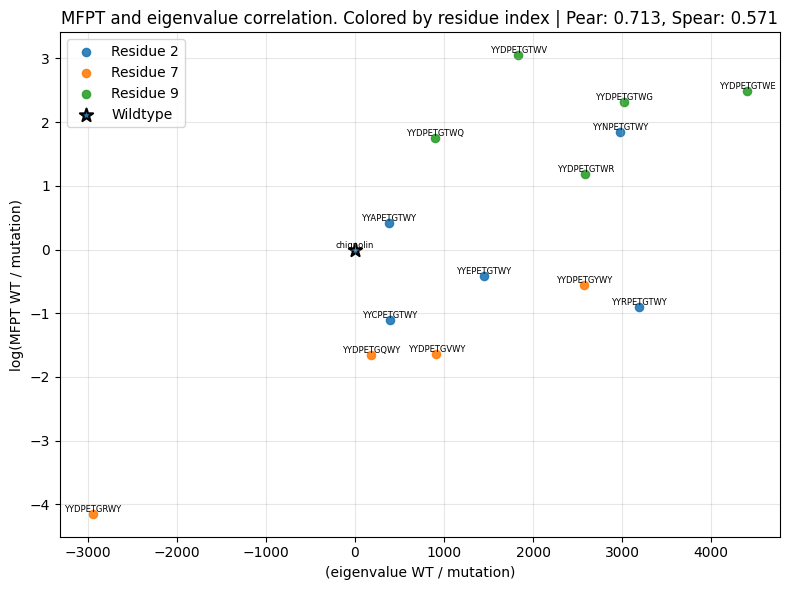

(0.71322014784004, 0.5714285714285713)

In [ ]:
from scipy import stats
import numpy as np
import matplotlib.pyplot as plt

def plot_mfpt_corr(df, prop_col, wt_label='Wildtype', group_col='residue_idx',
                   annotate=False, th=None, log_prop=True):
    wt_mfpt = float(df.loc[wt_label, 'mfpt'])
    wt_prop = df.loc[wt_label, prop_col]

    def ratio_or_raw(wt, arr, use_log):
        arr = np.asarray(arr, float)
        if pd.isna(wt):            # no WT value
            return arr
        if use_log:
            if wt <= 0 or np.any(arr <= 0):
                raise ValueError(f"Nonpositive values in '{prop_col}' — log undefined.")
            return wt - arr
        return wt - arr

    x_all = ratio_or_raw(wt_prop, df[prop_col].to_numpy(), log_prop)
    y_all = np.log(wt_mfpt / df['mfpt'].to_numpy())
    mask = np.isfinite(x_all) & np.isfinite(y_all)

    pearson, _  = stats.pearsonr(x_all[mask], y_all[mask])
    spearman, _ = stats.spearmanr(x_all[mask], y_all[mask])

    res_keys = sorted(int(k) for k in df[group_col].dropna().unique())
    res_colors = color_map(res_keys) if 'color_map' in globals() else {k: None for k in res_keys}

    plt.figure(figsize=(8, 6))

    if annotate:
        for xv, yv, name in zip(x_all[mask], y_all[mask], df.loc[mask, 'long'].to_numpy()):
            plt.text(xv, yv, name, fontsize=6, ha='center', va='bottom')

    for k in res_keys:
        sub = df[df[group_col] == k]
        x = ratio_or_raw(wt_prop, sub[prop_col].to_numpy(), log_prop)
        y = np.log(wt_mfpt / sub['mfpt'].to_numpy())
        plt.scatter(x, y, label=f"Residue {k}", s=35, alpha=0.9, c=res_colors.get(k))

    if not pd.isna(wt_prop):
        plt.scatter(0 if log_prop else wt_prop, 0, s=100, marker='*',
                    edgecolors='k', linewidths=1.5, label=wt_label)

    xlabel = (f'({prop_col} WT / mutation)'
              if log_prop and not pd.isna(wt_prop)
              else prop_col)
    plt.xlabel(xlabel)
    plt.ylabel('log(MFPT WT / mutation)')
    t = f" | Th={th:.3g}" if th is not None else ""
    plt.title(f"MFPT and {prop_col} correlation. Colored by residue index | Pear: {pearson:.3g}, Spear: {spearman:.3g}{t}")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    return pearson, spearman

df = collect_df(all_mfpt, th, sample_size)


sample_size = 200
th = thresholds[1]

with open("../data/mfpt-pace=25000.pkl", "rb") as f:
    all_mfpt = pickle.load(f)

plot_mfpt_corr(df, 'eigenvalue', annotate=True)
# plot_mfpt_corr(df, 'dot', annotate=True)
# plot_mfpt_corr(df, 'avg_change_diff', annotate=True)

/tmp/ipykernel_2050/3181942052.py:46: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return float(1 / max.prediction), int(limit)
/tmp/ipykernel_2050/3181942052.py:46: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  return float(1 / max.prediction), int(limit)


chignolin (Wildtype): 2.98 us, extra: 16
YYCPETGTWY (D2C): 11.38 us, extra: 21
YYDPETGTWE (Y9E): 0.08891 us, extra: 12
YYRPETGTWY (D2R): 2.66 us, extra: 10
YYAPETGTWY (D2A): 1.963 us, extra: 21
YYDPETGQWY (T7Q): 23.63 us, extra: 16
YYDPETGTWG (Y9G): 0.03779 us, extra: 10
YYDPETGTWQ (Y9Q): 0.06702 us, extra: 10
YYNPETGTWY (D2N): 0.5173 us, extra: 12
YYEPETGTWY (D2E): 6.152 us, extra: 14
YYDPETGTWR (Y9R): 0.9614 us, extra: 20
YYDPETGVWY (T7V): 19.5 us, extra: 30
YYDPETGYWY (T7Y): 3.153 us, extra: 10
YYDPETGTWV (Y9V): 0.09873 us, extra: 17
YYDPETGRWY (T7R): 206.7 us, extra: 39
chignolin (Wildtype): 4.653 us, extra: 12
YYCPETGTWY (D2C): 14.08 us, extra: 20
YYDPETGTWE (Y9E): 0.3875 us, extra: 19
YYRPETGTWY (D2R): 11.54 us, extra: 24
YYAPETGTWY (D2A): 3.084 us, extra: 14
YYDPETGQWY (T7Q): 24.48 us, extra: 14
YYDPETGTWG (Y9G): 0.4607 us, extra: 53
YYDPETGTWQ (Y9Q): 0.8043 us, extra: 22
YYNPETGTWY (D2N): 0.7326 us, extra: 12
YYEPETGTWY (D2E): 7.003 us, extra: 13
YYDPETGTWR (Y9R): 1.426 us, ext

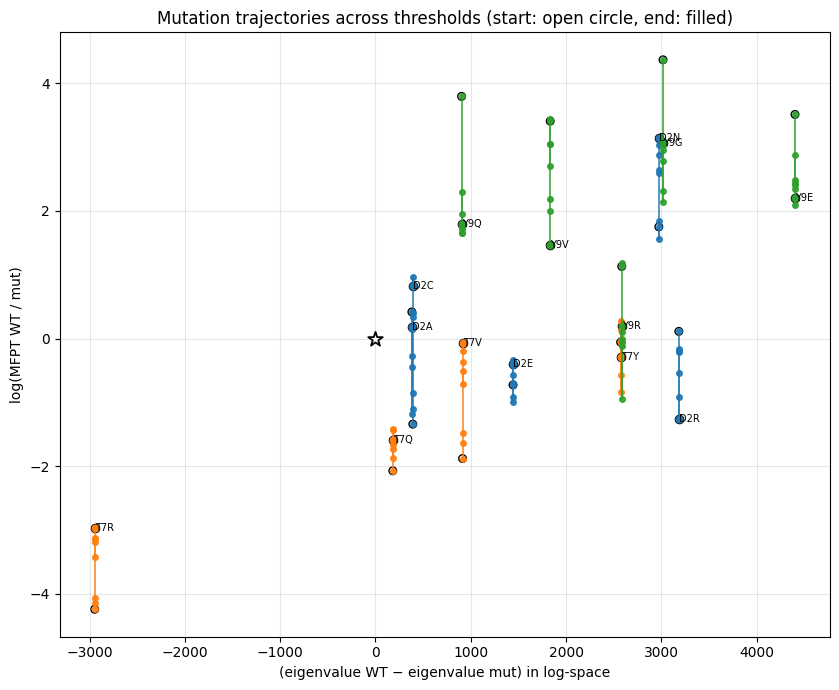

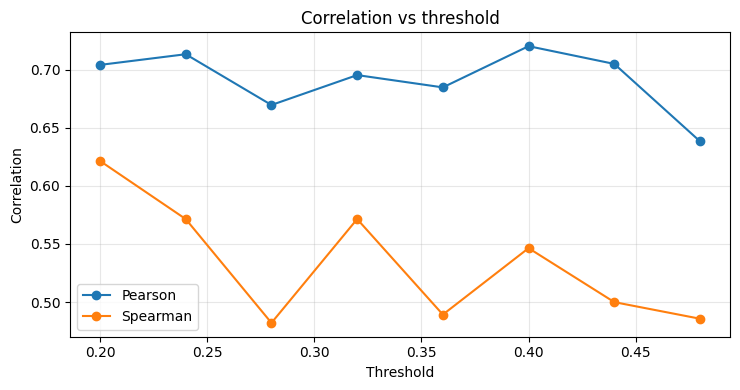

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

def plot_mfpt_trails(thresholds, collect_df, all_mfpt, sample_size,
                     prop_col='eigenvalue', wt_label='Wildtype',
                     group_col='residue_idx', log_prop=True,
                     annotate_end=True):
    """
    thresholds: iterable of threshold values (same ones you use to build df)
    collect_df: your function collect_df(all_mfpt, th, sample_size) -> df
    all_mfpt: whatever you pass today into collect_df
    sample_size: as you use today
    """

    # Build a df per threshold
    dfs = {th: collect_df(all_mfpt, th, sample_size) for th in thresholds}

    # Intersect indices so we track the same mutants across thresholds
    idx_common = set.intersection(*(set(df.index) for df in dfs.values()))
    if wt_label in idx_common:
        idx_common.remove(wt_label)  # we'll place WT separately at (0,0) if needed
    idx_common = sorted(idx_common)

    # Colors per residue
    # Try user color_map(res_keys), else assign from matplotlib
    res_keys = sorted({int(v) for df in dfs.values()
                       for v in df[group_col].dropna().unique()})
    if 'color_map' in globals():
        cmap = color_map(res_keys)
    else:
        base = plt.cm.get_cmap('tab20', len(res_keys))
        cmap = {k: base(i) for i, k in enumerate(res_keys)}

    def ratio_or_raw(wt, arr, use_log):
        arr = np.asarray(arr, float)
        if wt is None or (isinstance(wt, float) and np.isnan(wt)):
            return arr
        if use_log:
            if wt <= 0 or np.any(arr <= 0):
                raise ValueError(f"Nonpositive values in '{prop_col}' — log undefined.")
            return wt - arr
        return wt - arr

    # Precompute positions per mutant across thresholds
    trails = {}  # name -> dict(th -> (x, y))
    wt_xy = {}   # th -> (x_wt, y_wt) for plotting the WT star if desired

    for th, df in dfs.items():
        wt_mfpt = float(df.loc[wt_label, 'mfpt'])
        wt_prop = df.loc[wt_label, prop_col] if wt_label in df.index else np.nan

        # Save WT position (0,0 in log-ratio space if both defined)
        if not (isinstance(wt_prop, float) and np.isnan(wt_prop)):
            wt_xy[th] = (0 if log_prop else float(wt_prop), 0.0)
        else:
            wt_xy[th] = None

        # Compute per-mutant
        for name in idx_common:
            sub = df.loc[name]
            x = ratio_or_raw(wt_prop, np.array([sub[prop_col]]), log_prop)[0]
            y = np.log(wt_mfpt / float(sub['mfpt']))
            if name not in trails: trails[name] = {}
            trails[name][th] = (x, y)

    # Main figure: all thresholds as trajectories
    fig, ax = plt.subplots(figsize=(8.5, 7))
    for name in idx_common:
        # get residue idx + color
        any_df = next(iter(dfs.values()))
        res_id = any_df.loc[name, group_col]
        col = cmap.get(int(res_id), None)

        # order by thresholds for a clean path
        xy = np.array([trails[name][th] for th in thresholds if th in trails[name]])
        if xy.size == 0: 
            continue

        # draw trail
        ax.plot(xy[:,0], xy[:,1], marker='o', linewidth=1.2, markersize=4, alpha=0.9, c=col)

        # emphasize start/end
        ax.scatter(xy[0,0], xy[0,1], s=30, facecolors='none', edgecolors='k', linewidths=1.0)  # start = open circle
        ax.scatter(xy[-1,0], xy[-1,1], s=40, c=col, edgecolors='k', linewidths=0.6)           # end = filled

        # annotate end point
        if annotate_end:
            ax.text(xy[-1,0], xy[-1,1], name, fontsize=7, ha='left', va='center')

    # Optional: plot WT (0,0) once if defined
    if any(v is not None for v in wt_xy.values()):
        ax.scatter(0, 0, s=120, marker='*', edgecolors='k', linewidths=1.3, c='white', zorder=5, label=wt_label)

    xlabel = (f'({prop_col} WT − {prop_col} mut) in log-space'
              if log_prop else f'{prop_col} WT − {prop_col} mut')
    ax.set_xlabel(xlabel)
    ax.set_ylabel('log(MFPT WT / mut)')
    ax.set_title('Mutation trajectories across thresholds (start: open circle, end: filled)')

    # Build a tiny legend for residues (compact) — or comment out if too many
    # Create proxy artists for a few representative residues to keep legend small
    # (Skip if there are many residues; text clutter can be high.)
    # from matplotlib.lines import Line2D
    # proxies = [Line2D([0],[0], color=cmap[k], lw=3, label=f'Residue {k}') for k in res_keys[:6]]
    # ax.legend(handles=proxies + [plt.Line2D([0],[0], marker='*', color='w', markerfacecolor='w',
    #               markeredgecolor='k', label=wt_label, markersize=12)], frameon=True)

    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Bonus: correlation vs threshold line plot (helps see convergence)
    pearsons, spearmans = [], []
    for th, df in dfs.items():
        wt_mfpt = float(df.loc[wt_label, 'mfpt'])
        wt_prop = df.loc[wt_label, prop_col] if wt_label in df.index else np.nan

        x_all = ratio_or_raw(wt_prop, df[prop_col].to_numpy(), log_prop)
        y_all = np.log(wt_mfpt / df['mfpt'].to_numpy())
        mask = np.isfinite(x_all) & np.isfinite(y_all)

        p = stats.pearsonr(x_all[mask], y_all[mask])[0]
        s = stats.spearmanr(x_all[mask], y_all[mask])[0]
        pearsons.append(p); spearmans.append(s)

    fig2, ax2 = plt.subplots(figsize=(7.5, 4))
    ax2.plot(thresholds, pearsons, marker='o', label='Pearson')
    ax2.plot(thresholds, spearmans, marker='o', label='Spearman')
    ax2.set_xlabel('Threshold')
    ax2.set_ylabel('Correlation')
    ax2.set_title('Correlation vs threshold')
    ax2.grid(True, alpha=0.3)
    ax2.legend()
    plt.tight_layout()
    plt.show()


sample_size = 200
with open("../data/mfpt-pace=25000.pkl", "rb") as f:
    all_mfpt = pickle.load(f)

# e.g., visualize thresholds[0..7]
ths = thresholds[:8]

plot_mfpt_trails(
    thresholds=ths,
    collect_df=collect_df,
    all_mfpt=all_mfpt,
    sample_size=sample_size,
    prop_col='eigenvalue',
    wt_label='Wildtype',
    group_col='residue_idx',
    log_prop=True,
    annotate_end=True
)

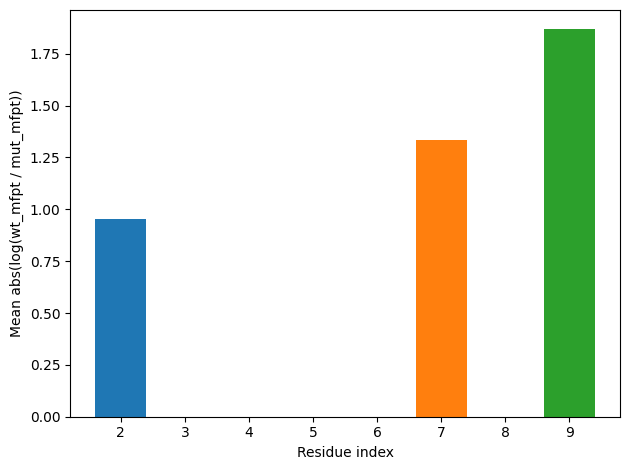

In [6]:

wt_mfpt = float(df.loc['Wildtype', 'mfpt'])
res_keys = sorted(int(k) for k in df['residue_idx'].dropna().unique())
res_colors = color_map(res_keys) if 'color_map' in globals() else {k: None for k in res_keys}

for i, group in df.groupby("residue_idx"):
    mfpt = group["mfpt"].to_numpy()

    val = np.abs(np.log((wt_mfpt / mfpt))).mean()
    
    plt.bar(i, val, color=res_colors[i])

plt.xlabel("Residue index")
plt.ylabel("Mean abs(log(wt_mfpt / mut_mfpt))")
plt.tight_layout()
plt.show()
# Highest - 9th
# Mid - 2nd
# Low - 7th


In [7]:


def fit_exp_ks(samples):
    x = np.array(samples)
    x.sort()

    n = x.size
    ecdf = np.arange(1, n + 1) / n
    def F(t, tau): return 1 - np.exp(-t / tau)
    
    tau = optimize.curve_fit(lambda t, tau: F(t, tau), x, ecdf, p0=(x.mean(),), bounds=(0, np.inf))[0][0]
    D, p = stats.kstest(x, "expon", args=(0, tau))
    return tau, p, D

/tmp/ipykernel_2050/3181942052.py:46: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return float(1 / max.prediction), int(limit)
/tmp/ipykernel_2050/3181942052.py:46: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  return float(1 / max.prediction), int(limit)


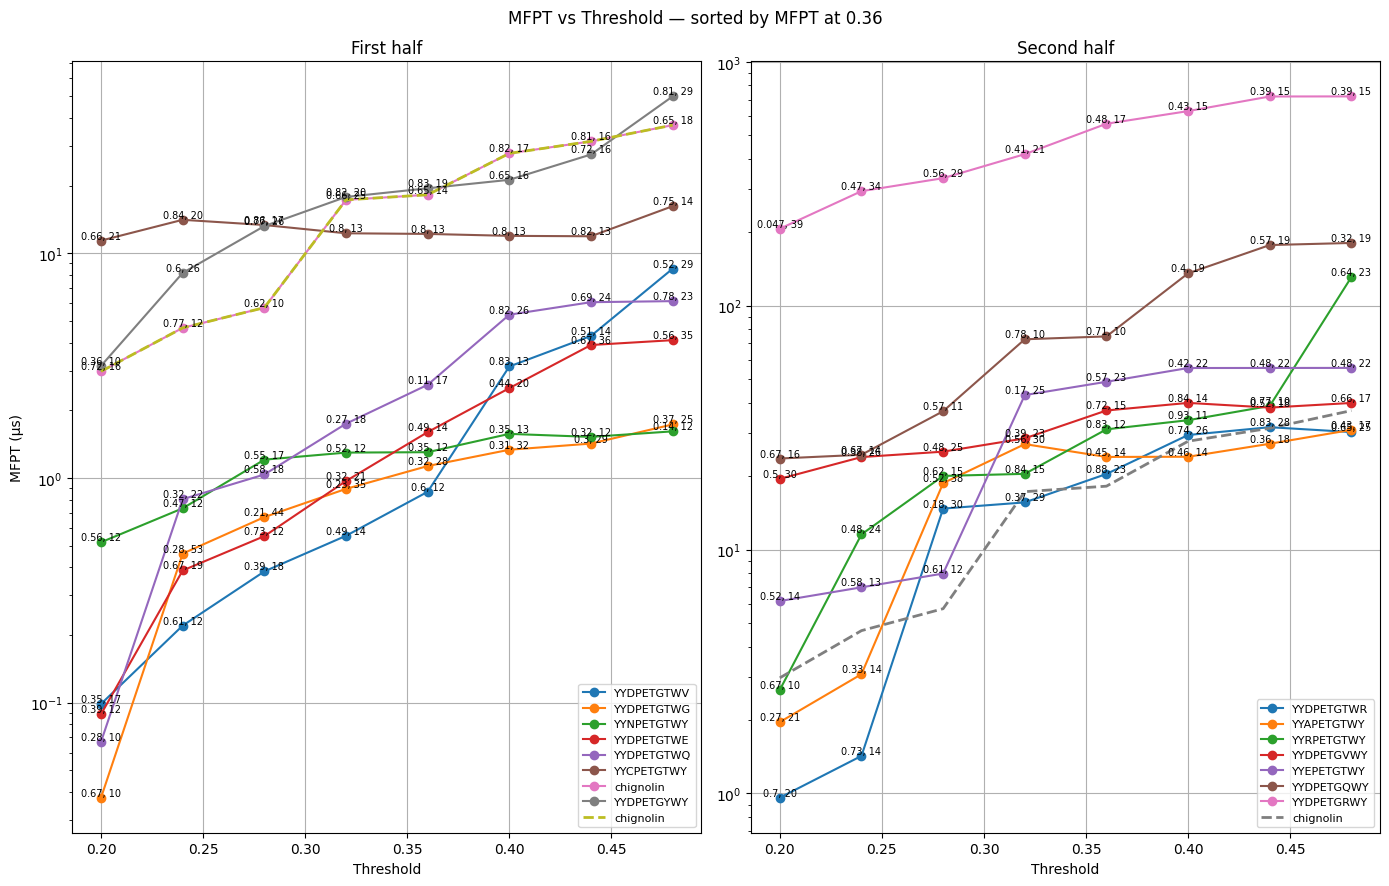

['YYDPETGTWV',
 'YYDPETGTWG',
 'YYNPETGTWY',
 'YYDPETGTWE',
 'YYDPETGTWQ',
 'YYCPETGTWY',
 'chignolin',
 'YYDPETGYWY',
 'YYDPETGTWR',
 'YYAPETGTWY',
 'YYRPETGTWY',
 'YYDPETGVWY',
 'YYEPETGTWY',
 'YYDPETGQWY',
 'YYDPETGRWY']

In [8]:
from scipy import stats, optimize

def plot_all_mfpt(all_mfpt, proteins, thresholds, sort_idx=4):
    """
    Sort proteins by ascending MFPT at thresholds[sort_idx] and plot side-by-side
    with independent y-scales and legends.
    """
    sort_idx = max(0, min(sort_idx, len(thresholds) - 1))

    # Collect MFPT (µs)
    series = {p: [] for p in proteins}
    pValues = {p: [] for p in proteins}
    chig = []

    for th in thresholds:
        s = np.sort(np.array(all_mfpt['chignolin'][th]))
        chig_mfpt, lim = estimateMFPT(s, 10)
        chig.append(chig_mfpt / 1e6)

        for p in proteins:
            s = np.sort(np.array(all_mfpt[p][th]))
            mfpt, lim = estimateMFPT(s, 10)
            series[p].append(mfpt / 1e6)
            tau, pValue, D = fit_exp_ks(s[:lim])

            pValues[p].append((pValue, lim))

    def sort_key(p):
        return series[p][sort_idx]

    proteins_sorted = sorted(proteins, key=sort_key)

    mid = (len(proteins_sorted) + 1) // 2
    halves = [proteins_sorted[:mid], proteins_sorted[mid:]]

    fig, axes = plt.subplots(1, 2, figsize=(14, 9), sharey=False)
    ref_th = thresholds[sort_idx]

    for ax, subset, title_suffix in zip(axes, halves, ['First half', 'Second half']):
        for p in subset:
            ax.plot(thresholds, series[p], marker='o', label=p)

            for x, y, (p, lim) in zip(thresholds,series[p], pValues[p]):
                ax.text(x, y, f"{p:.2g}, {lim}", ha='center', va='bottom', fontsize=7)

        ax.plot(thresholds, chig, linestyle='--', linewidth=2, label='chignolin')
        ax.set_xlabel('Threshold')
        ax.set_title(f'{title_suffix}')
        ax.set_yscale('log')
        ax.legend(fontsize=8, ncol=1)
        ax.grid(True)

    axes[0].set_ylabel('MFPT (µs)')
    fig.suptitle(f'MFPT vs Threshold — sorted by MFPT at {ref_th:.3g}')

    plt.tight_layout()
    plt.show()

    return proteins_sorted

plot_all_mfpt(all_mfpt, proteins, thresholds)


/tmp/ipykernel_2754307/1221575091.py:46: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return float(1 / max.prediction), int(limit)
/tmp/ipykernel_2754307/1221575091.py:46: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  return float(1 / max.prediction), int(limit)


37135481.21158646 18


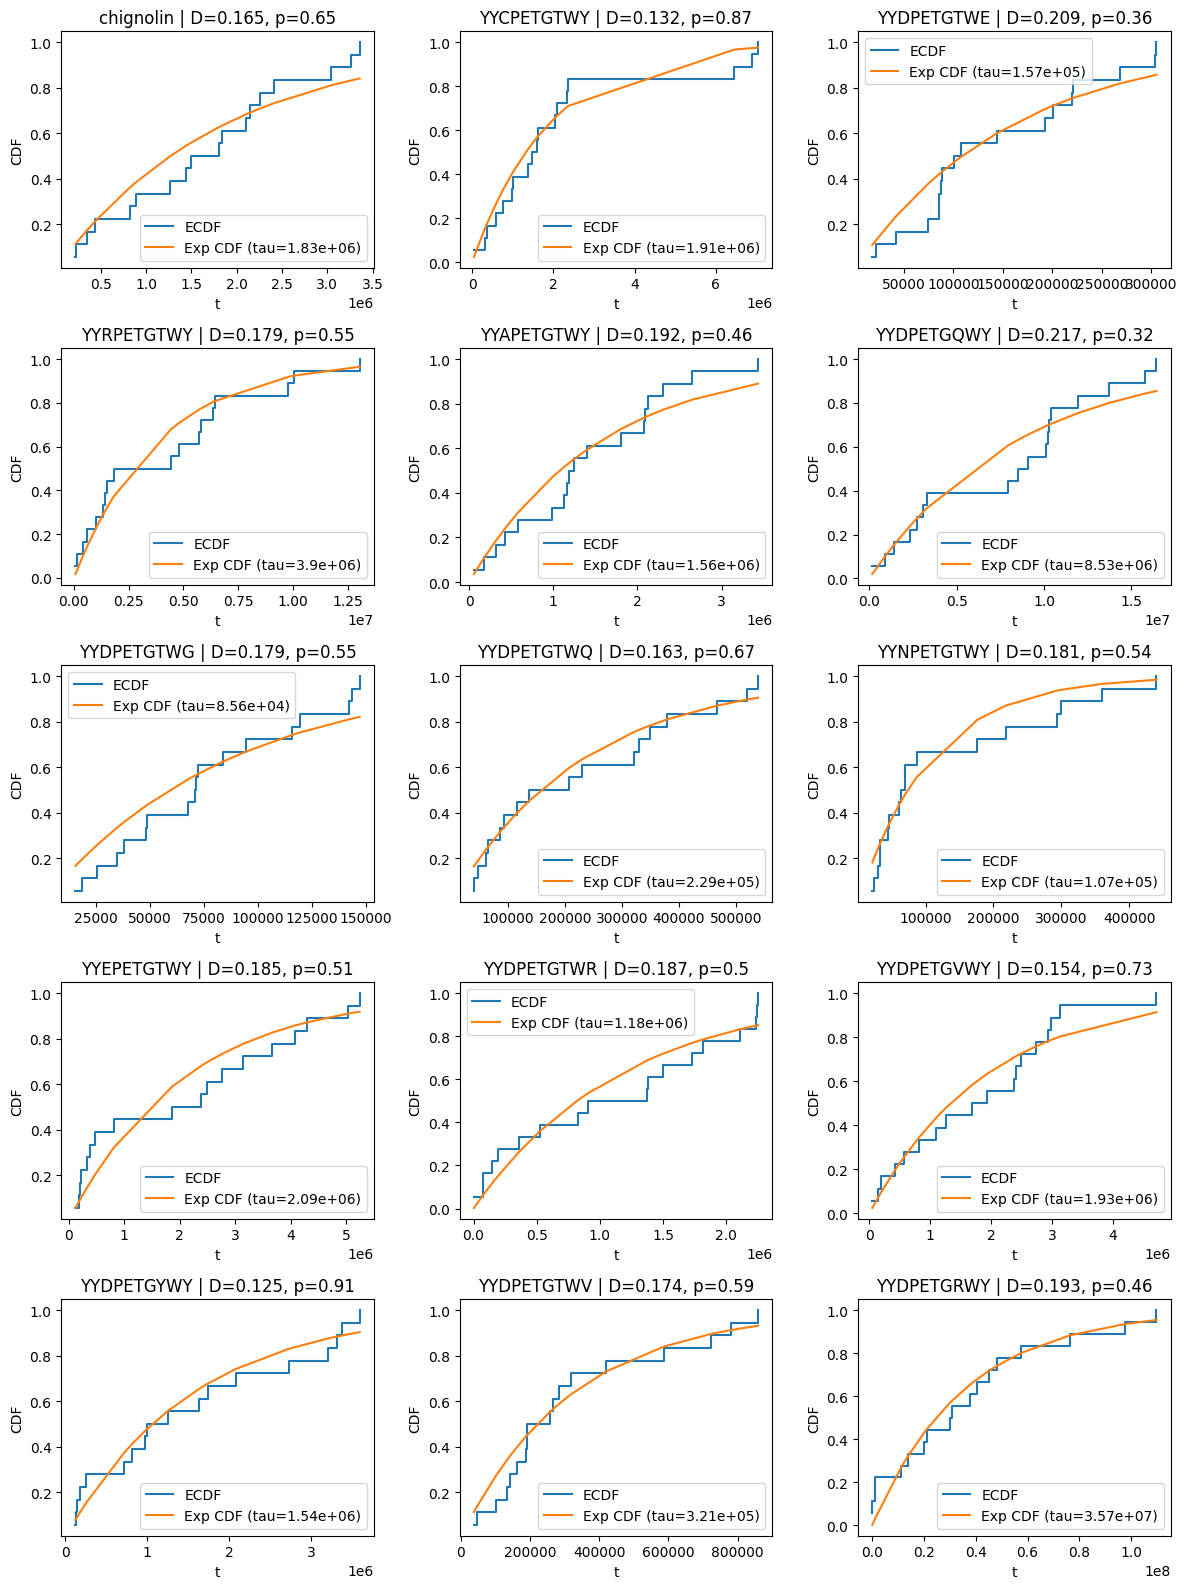

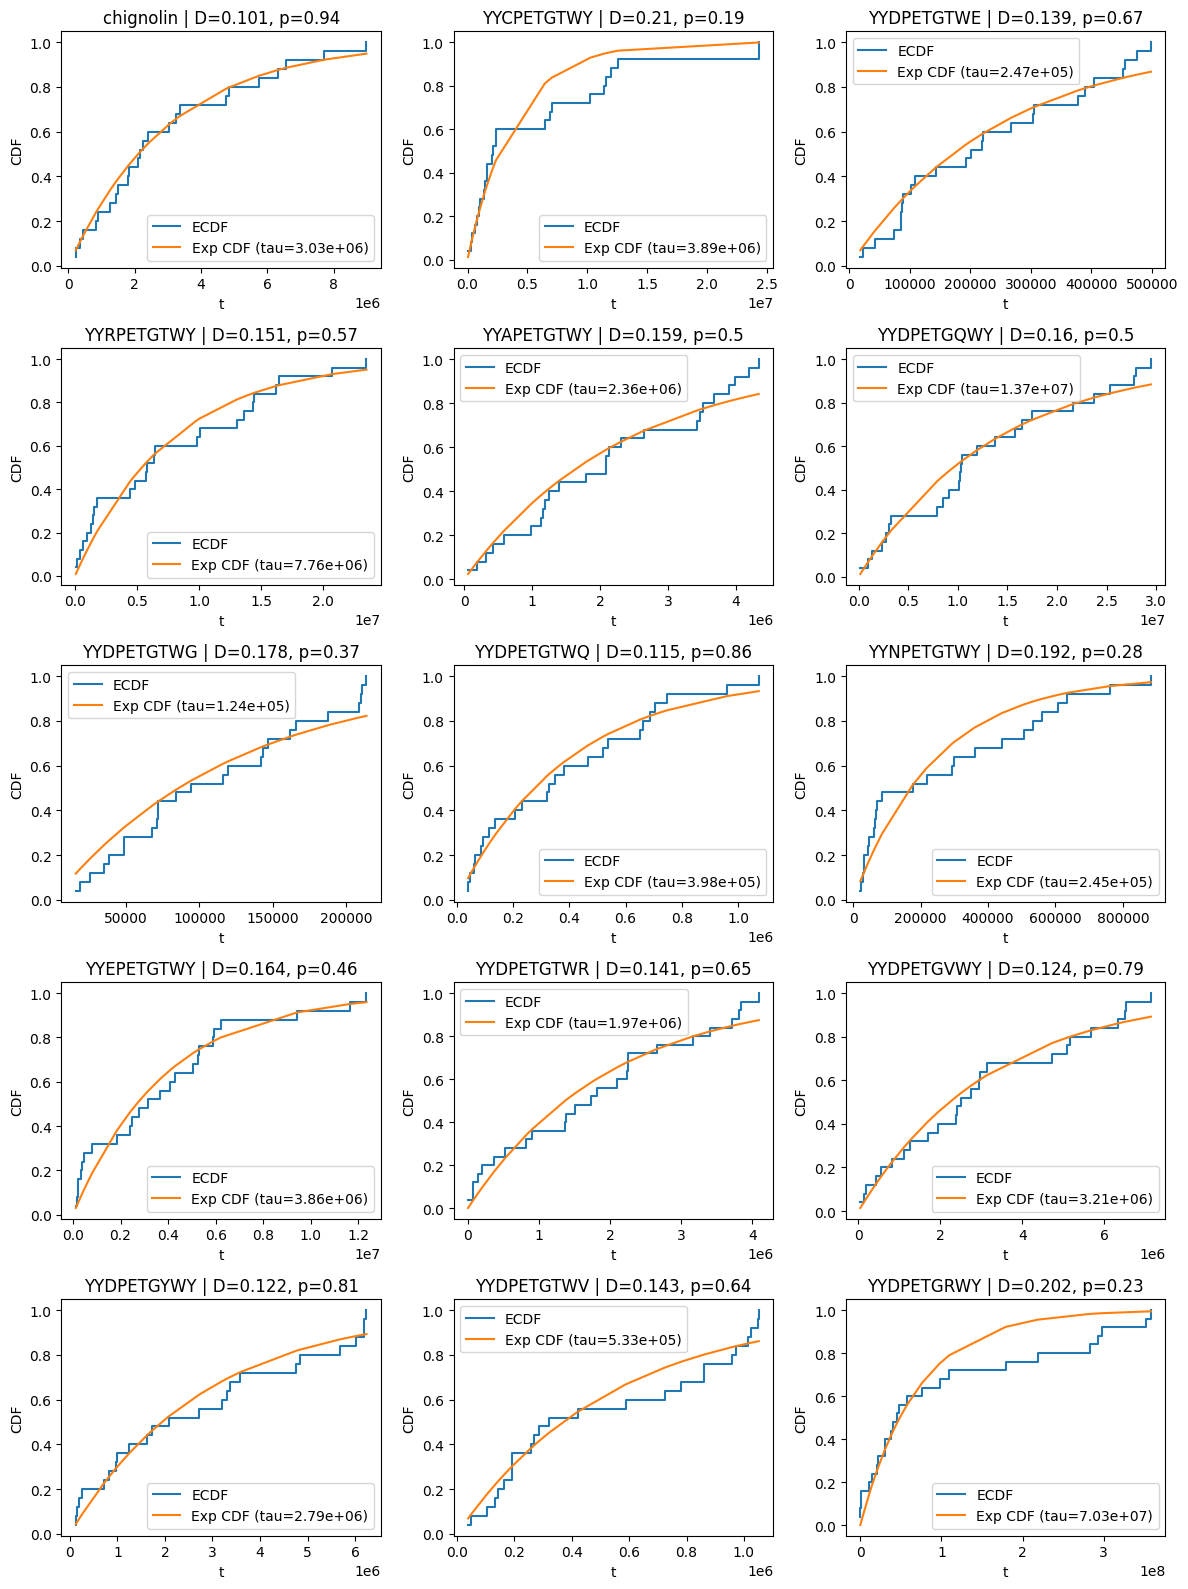

      name  k_fixed    tau_fixed  D_fixed  p_fixed  k_dyn      tau_dyn    D_dyn    p_dyn
 chignolin       25 3.034267e+06 0.101168 0.937536     18 1.833687e+06 0.165341 0.649660
YYCPETGTWY       25 3.885175e+06 0.209831 0.191632     14 1.321168e+06 0.171362 0.745007
YYDPETGTWE       25 2.466328e+05 0.139370 0.665685     35 3.961476e+05 0.128924 0.562029
YYRPETGTWY       25 7.757431e+06 0.151216 0.565691     23 6.510767e+06 0.147825 0.643164
YYAPETGTWY       25 2.355057e+06 0.158685 0.504884     17 1.436673e+06 0.202885 0.429310
YYDPETGQWY       25 1.369783e+07 0.159910 0.495175     19 9.159163e+06 0.211325 0.317898
YYDPETGTWG       25 1.238408e+05 0.177581 0.366020     25 1.238408e+05 0.177581 0.366020
YYDPETGTWQ       25 3.978473e+05 0.114587 0.861285     23 3.430530e+05 0.130303 0.783070
YYNPETGTWY       25 2.450327e+05 0.192243 0.276734     12 5.614952e+04 0.316262 0.144781
YYEPETGTWY       25 3.864358e+06 0.163923 0.463979     22 3.017067e+06 0.172001 0.480863
YYDPETGTWR       25 1

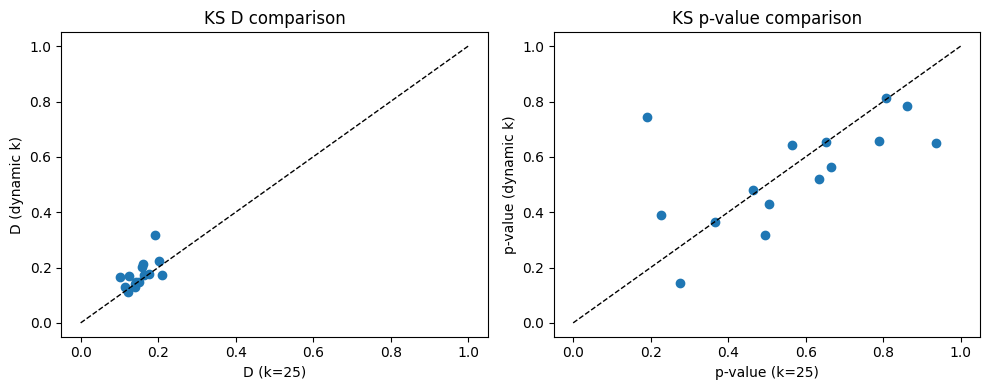

In [48]:
import math 

def fit_exp_ecdf(samples, ax):
    x = np.array(samples)

    n = x.size
    def F(t, tau): return 1 - np.exp(-t / tau)
    ecdf = np.arange(1, n + 1) / n
    tau = optimize.curve_fit(lambda t, tau: F(t, tau), x, ecdf, p0=(x.mean(),), bounds=(0, np.inf))[0][0]
    th = stats.expon.cdf(x, scale=tau)

    ax.step(x, ecdf, where="post", label="ECDF")
    ax.plot(x, th, label=f"Exp CDF (tau={tau:.3g})")
    D, p = stats.kstest(x, "expon", args=(0, tau))
    ax.set_xlabel("t"); ax.set_ylabel("CDF"); ax.legend(); ax.set_title(f"D={D:.3g}, p={p:.2g}")
    return tau, D, p, ax

def ks_table_fastest_k(all_mfpt, names, th, k):
    rows = []
    for name in names:
        s = np.array(all_mfpt[name][th])
        s.sort()
        
        s = s[:k]
        tau, p, D = fit_exp_ks(s)
        rows.append({"name": name, "n": s.size, "tau": tau, "ks_p": p, "ks_D": D})
    return pd.DataFrame(rows).sort_values("ks_p", ascending=False)

def plot_ecdfs_grid_fastest_k(all_mfpt, names, th, k = None ):
    ncols=3
    m = len(names)
    nrows = math.ceil(m / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(4*ncols, 3.2*nrows), squeeze=False)
    for i, name in enumerate(names):
        r, c = divmod(i, ncols)
        if k == None:
            mfpt_base, k = estimateMFPT(np.array(all_mfpt[name][th]), 10)
            print(mfpt_base, k)

        s = np.sort(np.array(all_mfpt[name][th]))[:k]
        fit_exp_ecdf(s, ax=axes[r, c])
        axes[r, c].set_title(f"{name} | " + axes[r, c].get_title())
        
    fig.tight_layout()
    return fig

# --- Your existing usage ---
th = thresholds[-1]
names = list(proteins)
k = 25
res = ks_table_fastest_k(all_mfpt, names, th, k = k)

plot_ecdfs_grid_fastest_k(all_mfpt, names, th)
plt.show()

plot_ecdfs_grid_fastest_k(all_mfpt, names, th, k = k)
plt.show()

def compare_k_vs_dynamic(all_mfpt, names, th, k = k):
    rows = []
    for name in names:
        s_all = np.sort(np.array(all_mfpt[name][th]))

        s_fixed = s_all[:k]
        fig, ax = plt.subplots()
        tau_f, D_f, p_f, _ = fit_exp_ecdf(s_fixed, ax=ax)
        plt.close(fig)

        # Dynamic k from estimateMFPT
        _, k_dyn = estimateMFPT(s_all, 10)
        s_dyn = s_all[:k_dyn]
        fig, ax = plt.subplots()
        tau_d, D_d, p_d, _ = fit_exp_ecdf(s_dyn, ax=ax)
        plt.close(fig)

        rows.append({
            "name": name,
            "k_fixed": k, "tau_fixed": tau_f, "D_fixed": D_f, "p_fixed": p_f,
            "k_dyn": k_dyn, "tau_dyn": tau_d, "D_dyn": D_d, "p_dyn": p_d
        })

    df = pd.DataFrame(rows)
    print(df.to_string(index=False))

    # Scatter plot comparison
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].scatter(df["D_fixed"], df["D_dyn"])
    axes[0].plot([0, 1], [0, 1], 'k--', lw=1)
    axes[0].set_xlabel(f"D (k={k})")
    axes[0].set_ylabel("D (dynamic k)")
    axes[0].set_title("KS D comparison")

    axes[1].scatter(df["p_fixed"], df["p_dyn"])
    axes[1].plot([0, 1], [0, 1], 'k--', lw=1)
    axes[1].set_xlabel(f"p-value (k={k})")
    axes[1].set_ylabel("p-value (dynamic k)")
    axes[1].set_title("KS p-value comparison")

    fig.tight_layout()
    return df, fig

# Run comparison
df_comparison, fig_cmp = compare_k_vs_dynamic(all_mfpt, names, th)
plt.show()
